<a href="https://colab.research.google.com/github/AKSHAYBHAMMAR/FLIGHT_RISK_PREDICTION_SYSTEM/blob/main/FLIGHT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter Departure City: MUMBAI
Enter Destination City: Baramati

===== ROUTE ANALYSIS =====

Point 1
Temp: 27.68°C | Wind: 5.34 | Visibility: 10.0 km | Humidity: 75%
Predicted Delay: 11.43 min

Point 2
Temp: 27.08°C | Wind: 2.47 | Visibility: 10.0 km | Humidity: 73%
Predicted Delay: 12.01 min

Point 3
Temp: 25.11°C | Wind: 1.02 | Visibility: 10.0 km | Humidity: 82%
Predicted Delay: 30.54 min

Point 4
Temp: 23.61°C | Wind: 2.14 | Visibility: 10.0 km | Humidity: 80%
Predicted Delay: 11.82 min

Point 5
Temp: 25.34°C | Wind: 2.14 | Visibility: 10.0 km | Humidity: 56%
Predicted Delay: 13.24 min

Point 6
Temp: 24.33°C | Wind: 2.26 | Visibility: 10.0 km | Humidity: 48%
Predicted Delay: 13.81 min

Point 7
Temp: 26.3°C | Wind: 4.04 | Visibility: 10.0 km | Humidity: 45%
Predicted Delay: 13.69 min

Point 8
Temp: 27.3°C | Wind: 4.06 | Visibility: 10.0 km | Humidity: 46%
Predicted Delay: 13.73 min

===== FINAL RESULT =====
Route: Mumbai → Baramati
Total Distance: 206.45 km
Estimated Delay: 14.7 minut

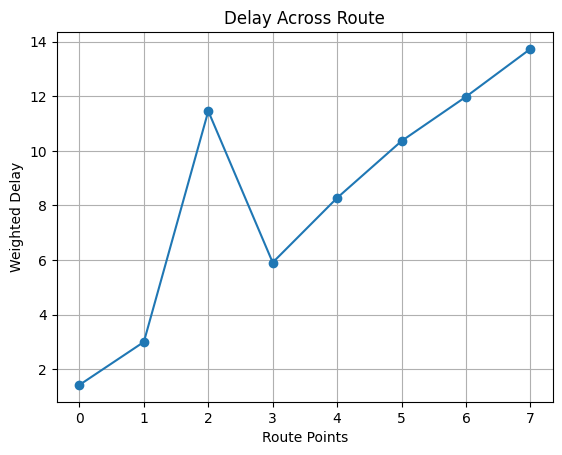

In [ ]:
# ================== IMPORTS ==================
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# ================== WEATHER API ==================
API_KEY = "1ba7a5c4137bda36dd6a1b0736778a63"

# ================== DISTANCE ==================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c


# ================== API FUNCTIONS ==================
def get_coordinates(city):
    city = city.strip()

    try:
        url = f"http://api.openweathermap.org/geo/1.0/direct?q={city}&limit=1&appid={API_KEY}"
        res = requests.get(url, timeout=5).json()

        if not res:
            raise ValueError(f"City '{city}' not found")

        return res[0]['lat'], res[0]['lon']

    except Exception as e:
        print("❌", e)
        return None, None


def get_weather(lat, lon):
    try:
        url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"
        data = requests.get(url, timeout=5).json()

        temp = data['main']['temp']
        humidity = data['main']['humidity']
        wind = data['wind']['speed']
        visibility = data.get('visibility', 10000) / 1000

        return temp, wind, visibility, humidity

    except:
        return 30, 10, 6, 70


# ================== WEATHER SEVERITY ==================
def weather_score(temp, wind, vis, hum):
    score = 0

    # Visibility (MOST IMPORTANT)
    if vis < 3:
        score += 40
    elif vis < 5:
        score += 25

    # Wind
    if wind > 15:
        score += 30
    elif wind > 10:
        score += 15

    # Humidity
    if hum > 80:
        score += 15

    # Temperature extremes
    if temp > 38 or temp < 10:
        score += 10

    return score


# ================== SYNTHETIC DATA ==================
data = []

for _ in range(1000):
    distance = np.random.randint(100, 2500)
    temp = np.random.randint(15, 45)
    wind = np.random.randint(2, 25)
    visibility = np.random.randint(1, 10)
    humidity = np.random.randint(30, 95)

    severity = weather_score(temp, wind, visibility, humidity)

    delay = (
        distance * 0.015 +
        severity * 1.2 +
        (10 - visibility) * 2 +
        np.random.normal(5, 3)
    )

    delay = max(delay, 0)

    data.append([distance, temp, wind, visibility, humidity, severity, delay])


df = pd.DataFrame(data, columns=[
    'distance_km', 'temperature', 'wind_speed',
    'visibility', 'humidity', 'severity', 'delay'
])

features = ['temperature', 'wind_speed', 'visibility', 'humidity', 'distance_km', 'severity']

X = df[features]
y = df['delay']


# ================== MODEL ==================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor(n_estimators=300, max_depth=12)
model.fit(X_train, y_train)


# ================== PREDICTION ==================
def predict_delay(temp, wind, vis, hum, distance):
    severity = weather_score(temp, wind, vis, hum)

    input_df = pd.DataFrame({
        'temperature': [temp],
        'wind_speed': [wind],
        'visibility': [vis],
        'humidity': [hum],
        'distance_km': [distance],
        'severity': [severity]
    })

    return round(model.predict(input_df)[0], 2)


# ================== ROUTE ==================
def get_route_points(lat1, lon1, lat2, lon2, num_points=8):
    lats = np.linspace(lat1, lat2, num_points)
    lons = np.linspace(lon1, lon2, num_points)
    return list(zip(lons, lats))


# ================== MAIN ==================
def analyze_route(dep, dest):

    lat1, lon1 = get_coordinates(dep)
    lat2, lon2 = get_coordinates(dest)

    if lat1 is None or lat2 is None:
        return

    total_distance = haversine(lat1, lon1, lat2, lon2)
    route_points = get_route_points(lat1, lon1, lat2, lon2)

    delays = []
    weights = []

    print("\n===== ROUTE ANALYSIS =====")

    for i, (lon, lat) in enumerate(route_points):

        temp, wind, vis, hum = get_weather(lat, lon)

        segment_dist = total_distance / len(route_points)
        delay = predict_delay(temp, wind, vis, hum, segment_dist)

        weight = (i + 1) / len(route_points)

        delays.append(delay * weight)
        weights.append(weight)

        print(f"\nPoint {i+1}")
        print(f"Temp: {temp}°C | Wind: {wind} | Visibility: {vis} km | Humidity: {hum}%")
        print(f"Predicted Delay: {delay} min")

    final_delay = sum(delays) / sum(weights)

    print("\n===== FINAL RESULT =====")
    print(f"Route: {dep.title()} → {dest.title()}")
    print(f"Total Distance: {round(total_distance,2)} km")
    print(f"Estimated Delay: {round(final_delay,2)} minutes")

    # Graph
    plt.figure()
    plt.plot([d for d in delays], marker='o')
    plt.title("Delay Across Route")
    plt.xlabel("Route Points")
    plt.ylabel("Weighted Delay")
    plt.grid()
    plt.show()


# ================== RUN ==================
if __name__ == "__main__":
    d = input("Enter Departure City: ")
    a = input("Enter Destination City: ")

    analyze_route(d, a)